In [19]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print("All libraries imported successfully!")

All libraries imported successfully!


# =====================================================================
# PREPROCESSING
# =====================================================================

## Step 1: Handling Identifier and Temporal Columns

In [20]:
# Load the dataset
df = pd.read_csv('/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/Data/Model_data.csv')

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("✅ Dataset loaded successfully!")
print(f"📊 Dataset dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Period covered: {df['timestamp'].min()} to {df['timestamp'].max()}")

✅ Dataset loaded successfully!
📊 Dataset dimensions: 210,528 rows × 20 columns
📅 Period covered: 2024-01-01 00:00:00 to 2025-12-31 23:55:00


In [21]:
# =====================================================================
# 1.1 Extract temporal components from timestamp
# =====================================================================

df['year']   = df['timestamp'].dt.year
df['month']  = df['timestamp'].dt.month
df['day']    = df['timestamp'].dt.day
df['hour']   = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df['second'] = df['timestamp'].dt.second
df['date'] = df['timestamp'].dt.date

print("Temporal columns extracted:")
print(df[['timestamp', 'year', 'month', 'day', 'hour', 'minute', 'second']].head(10))

Temporal columns extracted:
            timestamp  year  month  day  hour  minute  second
0 2024-01-01 00:00:00  2024      1    1     0       0       0
1 2024-01-01 00:05:00  2024      1    1     0       5       0
2 2024-01-01 00:10:00  2024      1    1     0      10       0
3 2024-01-01 00:15:00  2024      1    1     0      15       0
4 2024-01-01 00:20:00  2024      1    1     0      20       0
5 2024-01-01 00:25:00  2024      1    1     0      25       0
6 2024-01-01 00:30:00  2024      1    1     0      30       0
7 2024-01-01 00:35:00  2024      1    1     0      35       0
8 2024-01-01 00:40:00  2024      1    1     0      40       0
9 2024-01-01 00:45:00  2024      1    1     0      45       0


In [22]:
# =====================================================================
# 1.2 Drop non-predictive identifier and high correlated columns
# =====================================================================
# timestamp is kept in the DataFrame for reference but will be excluded from features (X) during modeling

columns_to_drop = ['date','packet_loss_rate_percent','rtt_ms','energy_efficiency_bits_per_joule','reliability_percent','throughput_ul_mbps','spectral_efficiency_bps_hz','bler_percent']
df.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped columns: {columns_to_drop}")
print(f"Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.")
print(f"\nNew dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nRemaining columns:\n{list(df.columns)}")

Dropped columns: ['date', 'packet_loss_rate_percent', 'rtt_ms', 'energy_efficiency_bits_per_joule', 'reliability_percent', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'bler_percent']
Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.

New dataset dimensions: 210,528 rows x 19 columns

Remaining columns:
['timestamp', 'slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'packet_loss_percent', 'throughput_dl_mbps', 'handover_success_rate_percent', 'anomaly', 'anomaly_type', 'year', 'month', 'day', 'hour', 'minute', 'second']


In [23]:
# =====================================================================
# 1.3 Encode slice_type (Label Encoding)
# =====================================================================
# Only 3 categories (eMBB, URLLC, mMTC) -> Label Encoding is sufficient

le_slice = LabelEncoder()
df['slice_type'] = le_slice.fit_transform(df['slice_type'])

print("slice_type encoding (Label Encoding):")
for label, encoded in zip(le_slice.classes_, le_slice.transform(le_slice.classes_)):
    print(f"   {label} -> {encoded}")

print(f"\nDistribution after encoding:")
print(df['slice_type'].value_counts().sort_index())

slice_type encoding (Label Encoding):
   URLLC -> 0

Distribution after encoding:
slice_type
0    210528
Name: count, dtype: int64


In [24]:
# =====================================================================
# 1.4 DataFrame state verification after Step 1
# =====================================================================

print("="*70)
print("VERIFICATION - DATAFRAME STATE AFTER STEP 1")
print("="*70)
print(f"\nDimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nPreview:")
df.head()

VERIFICATION - DATAFRAME STATE AFTER STEP 1

Dimensions: 210,528 rows x 19 columns

Column types:
timestamp                        datetime64[ns]
slice_type                                int64
latitude                                float64
longitude                               float64
one_way_latency_ms                      float64
jitter_ms                               float64
packet_delay_budget_ms                  float64
handover_interruption_time_ms           float64
packet_loss_percent                     float64
throughput_dl_mbps                      float64
handover_success_rate_percent           float64
anomaly                                   int64
anomaly_type                             object
year                                      int32
month                                     int32
day                                       int32
hour                                      int32
minute                                    int32
second                                

,timestamp,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,packet_delay_budget_ms,handover_interruption_time_ms,packet_loss_percent,throughput_dl_mbps,handover_success_rate_percent,anomaly,anomaly_type,year,month,day,hour,minute,second
0,2024-01-01 00:00:00,0,33.800386,-7.547638,2.5865,0.5029,0.7614,5.2166,0.0005,106.5463,99.5036,0,normal,2024,1,1,0,0,0
1,2024-01-01 00:05:00,0,33.802700,-7.553952,2.4543,0.4950,0.7626,5.0939,0.0005,102.3002,99.4860,0,normal,2024,1,1,0,5,0
2,2024-01-01 00:10:00,0,33.800517,-7.556512,2.4245,0.4927,0.7753,5.1232,0.0005,97.0391,99.4985,0,normal,2024,1,1,0,10,0
3,2024-01-01 00:15:00,0,33.803398,-7.559040,2.4348,0.4907,0.7673,5.0829,0.0005,96.8969,99.5141,0,normal,2024,1,1,0,15,0
4,2024-01-01 00:20:00,0,33.809118,-7.551471,2.3904,0.4889,0.7729,5.0481,0.0005,101.7346,99.5181,0,normal,2024,1,1,0,20,0


In [25]:
# =====================================================================
# Create a clean copy of the DataFrame for preprocessing
# =====================================================================
# df is preserved as the original (post-Step 1), df_clean is used from now on

df_clean = df.copy()

print(f"df_clean created: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Original df is preserved separately.")

df_clean created: 210,528 rows x 19 columns
Original df is preserved separately.


## 2. Feautres and Target Separation:

In [26]:
# =====================================================================
# 2.1 Define Features (X) and Targets (y1, y2)
# =====================================================================

# Columns to exclude from features
exclude_cols = ['timestamp', 'anomaly', 'anomaly_type']

# Features: 10 KPIs + slice_type (encoded) + latitude + longitude + 6 temporal components
X = df_clean.drop(columns=exclude_cols)

# Target 1: Binary classification (0 = Normal, 1 = Anomaly)
y1 = df_clean['anomaly']

# Target 2: Multi-class classification (9 anomaly types)
le_anomaly = LabelEncoder()
y2 = le_anomaly.fit_transform(df_clean['anomaly_type'])

print("="*70)
print("FEATURES / TARGETS SEPARATION")
print("="*70)

print(f"\nFeatures (X): {X.shape[1]} columns")
print(f"   {list(X.columns)}")
print(f"\nTarget y1 (binary): anomaly")
print(f"   Classes: {sorted(y1.unique())} -> 0=Normal, 1=Anomaly")
print(f"   Distribution: {dict(y1.value_counts().sort_index())}")
print(f"\nTarget y2 (multi-class): anomaly_type")
print(f"   Encoding:")
for label, encoded in zip(le_anomaly.classes_, le_anomaly.transform(le_anomaly.classes_)):
    print(f"      {label} -> {encoded}")
print(f"   Distribution: {dict(pd.Series(y2).value_counts().sort_index())}")

FEATURES / TARGETS SEPARATION

Features (X): 16 columns
   ['slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'packet_loss_percent', 'throughput_dl_mbps', 'handover_success_rate_percent', 'year', 'month', 'day', 'hour', 'minute', 'second']

Target y1 (binary): anomaly
   Classes: [np.int64(0), np.int64(1)] -> 0=Normal, 1=Anomaly
   Distribution: {0: np.int64(206127), 1: np.int64(4401)}

Target y2 (multi-class): anomaly_type
   Encoding:
      backhaul_issue -> 0
      handover_failure -> 1
      hardware_failure -> 2
      interference -> 3
      network_congestion -> 4
      normal -> 5
      overload -> 6
      security_attack -> 7
      signal_degradation -> 8
   Distribution: {0: np.int64(628), 1: np.int64(583), 2: np.int64(501), 3: np.int64(557), 4: np.int64(475), 5: np.int64(206127), 6: np.int64(519), 7: np.int64(509), 8: np.int64(629)}


In [27]:
# =====================================================================
# 2.2 Verification: shapes and types
# =====================================================================

print("="*70)
print("VERIFICATION - STEP 2")
print("="*70)

print(f"\n  X shape:  {X.shape}  ({X.shape[1]} features)")
print(f"  y1 shape: {y1.shape}  (binary)")
print(f"  y2 shape: {y2.shape}  (multi-class, {len(le_anomaly.classes_)} classes)")
print(f"\n  X dtypes:")
print(X.dtypes)
print(f"\n  X preview:")
X.head()

VERIFICATION - STEP 2

  X shape:  (210528, 16)  (16 features)
  y1 shape: (210528,)  (binary)
  y2 shape: (210528,)  (multi-class, 9 classes)

  X dtypes:
slice_type                         int64
latitude                         float64
longitude                        float64
one_way_latency_ms               float64
jitter_ms                        float64
packet_delay_budget_ms           float64
handover_interruption_time_ms    float64
packet_loss_percent              float64
throughput_dl_mbps               float64
handover_success_rate_percent    float64
year                               int32
month                              int32
day                                int32
hour                               int32
minute                             int32
second                             int32
dtype: object

  X preview:


,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,packet_delay_budget_ms,handover_interruption_time_ms,packet_loss_percent,throughput_dl_mbps,handover_success_rate_percent,year,month,day,hour,minute,second
0,0,33.800386,-7.547638,2.5865,0.5029,0.7614,5.2166,0.0005,106.5463,99.5036,2024,1,1,0,0,0
1,0,33.802700,-7.553952,2.4543,0.4950,0.7626,5.0939,0.0005,102.3002,99.4860,2024,1,1,0,5,0
2,0,33.800517,-7.556512,2.4245,0.4927,0.7753,5.1232,0.0005,97.0391,99.4985,2024,1,1,0,10,0
3,0,33.803398,-7.559040,2.4348,0.4907,0.7673,5.0829,0.0005,96.8969,99.5141,2024,1,1,0,15,0
4,0,33.809118,-7.551471,2.3904,0.4889,0.7729,5.0481,0.0005,101.7346,99.5181,2024,1,1,0,20,0


In [28]:
# =====================================================================
# 3.1 Train/Test Split for Binary Classification (y1)
# =====================================================================
# 80% train / 20% test, stratified to preserve class imbalance

X_train_b, X_test_b, y1_train, y1_test = train_test_split(
    X, y1, test_size=0.2, random_state=42, stratify=y1
)

print("="*70)
print("TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)")
print("="*70)
print(f"\n  X_train: {X_train_b.shape}")
print(f"  X_test:  {X_test_b.shape}")
print(f"\n  y1_train distribution:")
print(f"    Normal (0):  {(y1_train == 0).sum():,} ({(y1_train == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_train == 1).sum():,} ({(y1_train == 1).mean()*100:.2f}%)")
print(f"\n  y1_test distribution:")
print(f"    Normal (0):  {(y1_test == 0).sum():,} ({(y1_test == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_test == 1).sum():,} ({(y1_test == 1).mean()*100:.2f}%)")

# =====================================================================
# 3.2 Train/Test Split for Multi-class Classification (y2)
# =====================================================================
# 80% train / 20% test, stratified to preserve all 9 class proportions

X_train_m, X_test_m, y2_train, y2_test = train_test_split(
    X, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f"\n{'='*70}")
print("TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)")
print("="*70)
print(f"\n  X_train: {X_train_m.shape}")
print(f"  X_test:  {X_test_m.shape}")
print(f"\n  y2_train distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_train == encoded).sum()
    pct = count / len(y2_train) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")
print(f"\n  y2_test distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_test == encoded).sum()
    pct = count / len(y2_test) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")

TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)

  X_train: (168422, 16)
  X_test:  (42106, 16)

  y1_train distribution:
    Normal (0):  164,901 (97.91%)
    Anomaly (1): 3,521 (2.09%)

  y1_test distribution:
    Normal (0):  41,226 (97.91%)
    Anomaly (1): 880 (2.09%)

TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)

  X_train: (168422, 16)
  X_test:  (42106, 16)

  y2_train distribution:
    backhaul_issue (0): 502 (0.30%)
    handover_failure (1): 467 (0.28%)
    hardware_failure (2): 401 (0.24%)
    interference (3): 446 (0.26%)
    network_congestion (4): 380 (0.23%)
    normal (5): 164,901 (97.91%)
    overload (6): 415 (0.25%)
    security_attack (7): 407 (0.24%)
    signal_degradation (8): 503 (0.30%)

  y2_test distribution:
    backhaul_issue (0): 126 (0.30%)
    handover_failure (1): 116 (0.28%)
    hardware_failure (2): 100 (0.24%)
    interference (3): 111 (0.26%)
    network_congestion (4): 95 (0.23%)
    normal (5): 41,226 (97.91%)
    overload (6): 104 (0.25%)
    

## 4. Standardization (StandardScaler)

In [29]:
# =====================================================================
# 4.1 Apply StandardScaler
# =====================================================================
# Fit on training data ONLY, then transform both train and test sets
# This prevents data leakage from test set into training

scaler = StandardScaler()

# --- Binary classification sets ---
X_train_b_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_b),
    columns=X_train_b.columns,
    index=X_train_b.index
)
X_test_b_scaled = pd.DataFrame(
    scaler.transform(X_test_b),
    columns=X_test_b.columns,
    index=X_test_b.index
)

# --- Multi-class classification sets ---
scaler_m = StandardScaler()

X_train_m_scaled = pd.DataFrame(
    scaler_m.fit_transform(X_train_m),
    columns=X_train_m.columns,
    index=X_train_m.index
)
X_test_m_scaled = pd.DataFrame(
    scaler_m.transform(X_test_m),
    columns=X_test_m.columns,
    index=X_test_m.index
)

# =====================================================================
# 4.2 Verification
# =====================================================================
print("="*70)
print("STANDARDIZATION - StandardScaler")
print("="*70)

print("--- Binary classification sets ---")
print(f"  X_train_b_scaled: {X_train_b_scaled.shape}")
print(f"  X_test_b_scaled:  {X_test_b_scaled.shape}")

print(" Train set statistics (mean ~ 0, std ~ 1):")
train_stats = pd.DataFrame({
    "Mean": X_train_b_scaled.mean().round(6),
    "Std": X_train_b_scaled.std().round(6)
})
print(train_stats)

print("Test set statistics:")
test_stats = pd.DataFrame({
    "Mean": X_test_b_scaled.mean().round(6),
    "Std": X_test_b_scaled.std().round(6)
})
print(test_stats)

print("--- Multi-class classification sets ---")
print(f"  X_train_m_scaled: {X_train_m_scaled.shape}")
print(f"  X_test_m_scaled:  {X_test_m_scaled.shape}")

print("Preview (X_train_b_scaled):")
X_train_b_scaled.head()

STANDARDIZATION - StandardScaler
--- Binary classification sets ---
  X_train_b_scaled: (168422, 16)
  X_test_b_scaled:  (42106, 16)
 Train set statistics (mean ~ 0, std ~ 1):
                               Mean       Std
slice_type                      0.0  0.000000
latitude                       -0.0  1.000003
longitude                       0.0  1.000003
one_way_latency_ms              0.0  1.000003
jitter_ms                      -0.0  1.000003
packet_delay_budget_ms          0.0  1.000003
handover_interruption_time_ms  -0.0  1.000003
packet_loss_percent            -0.0  1.000003
throughput_dl_mbps             -0.0  1.000003
handover_success_rate_percent  -0.0  1.000003
year                           -0.0  1.000003
month                          -0.0  1.000003
day                            -0.0  1.000003
hour                            0.0  1.000003
minute                          0.0  1.000003
second                          0.0  0.000000
Test set statistics:
                     

,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,packet_delay_budget_ms,handover_interruption_time_ms,packet_loss_percent,throughput_dl_mbps,handover_success_rate_percent,year,month,day,hour,minute,second
38000,0.0,-2.311899,0.470150,-0.068084,-0.080454,-0.120537,-0.014758,-0.082691,0.069209,0.104043,-0.999157,-0.442551,-0.537601,1.517779,0.724767,0.0
66803,0.0,-0.337148,1.019846,-0.064099,-0.079627,-0.062109,-0.038860,-0.082691,0.018927,0.070918,-0.999157,0.427758,0.372097,1.517779,1.593922,0.0
5081,0.0,-0.951292,1.074995,-0.061371,-0.021519,-0.229096,-0.008077,-0.082691,-0.113561,0.093306,-0.999157,-1.602963,0.258385,0.506064,-0.144388,0.0
107831,0.0,-1.176092,0.486335,-0.089664,-0.086244,-0.089520,0.009514,-0.082691,0.561127,0.086323,1.000843,-1.602963,-0.765026,-0.361121,1.593922,0.0
129005,0.0,0.462361,0.676761,-0.080030,-0.060499,-0.016305,-0.036819,-0.082691,0.463725,0.072041,1.000843,-1.022757,0.826946,1.517779,-0.144388,0.0


## 5. Distribution des Features apres Standardisation

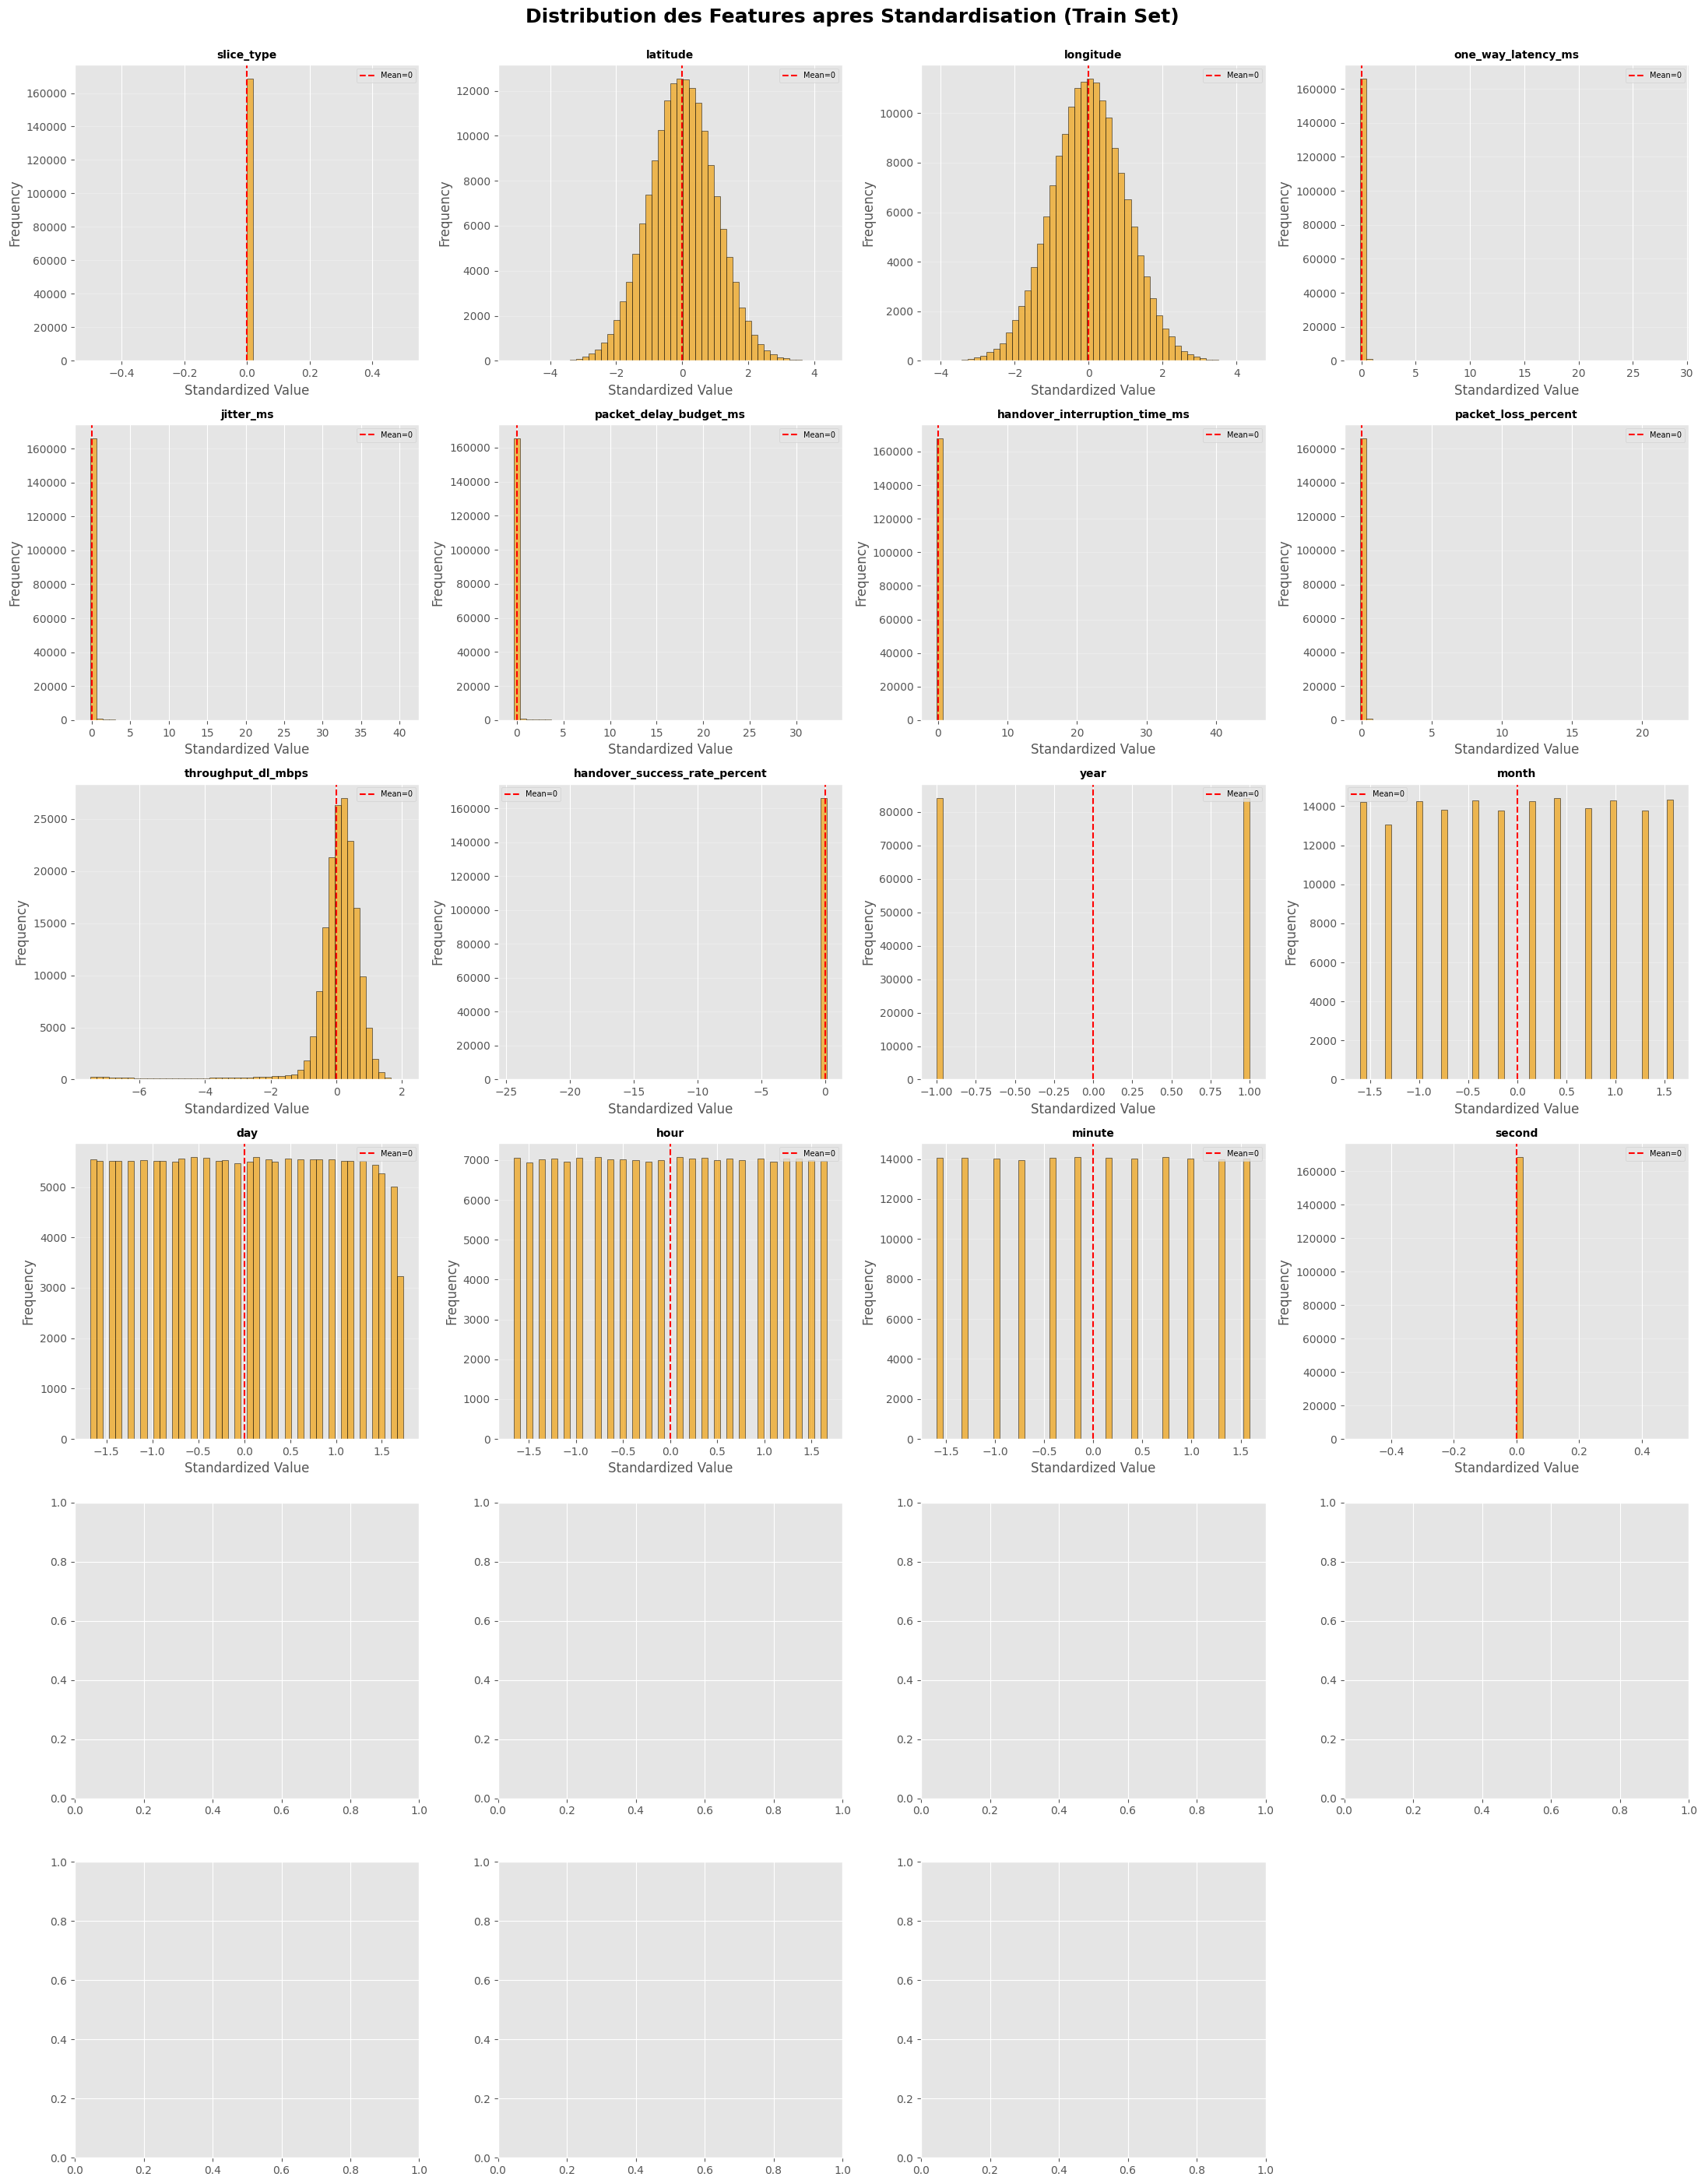

All 16 features are standardized (mean ~ 0, std ~ 1)


In [30]:
# =====================================================================
# 5. Distribution des Features apres Standardisation
# =====================================================================

fig, axes = plt.subplots(6, 4, figsize=(22, 28))
axes = axes.ravel()

for idx, col in enumerate(X_train_b_scaled.columns):
    axes[idx].hist(X_train_b_scaled[col], bins=50, color="#f0a10f",
                   alpha=0.7, edgecolor='black')
    axes[idx].set_title(col, fontsize=10, fontweight='bold')
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Mean=0')
    axes[idx].set_xlabel('Standardized Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend(fontsize=7)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide unused subplot (24 subplots, 23 features)
axes[-1].set_visible(False)

plt.suptitle('Distribution des Features apres Standardisation (Train Set)',
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"All {X_train_b_scaled.shape[1]} features are standardized (mean ~ 0, std ~ 1)")

## 5.bis Comparaison des Transformations : Yeo-Johnson vs Quantile Transformer

StandardScaler ne change pas la forme de la distribution (seulement mean=0, std=1).
Pour rapprocher les distributions d'une loi normale, on compare deux approches :
- **Yeo-Johnson (PowerTransformer)** : trouve automatiquement le lambda optimal par feature
- **QuantileTransformer (Gaussian)** : force une distribution normale parfaite

In [31]:
# =====================================================================
# 5.bis.1 Apply Yeo-Johnson and Quantile Transformers
# =====================================================================
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

# --- Yeo-Johnson PowerTransformer ---
pt_yj = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_b_yeojohnson = pd.DataFrame(
    pt_yj.fit_transform(X_train_b),
    columns=X_train_b.columns,
    index=X_train_b.index
)

# --- Quantile Transformer (Gaussian output) ---
qt_gauss = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
X_train_b_quantile = pd.DataFrame(
    qt_gauss.fit_transform(X_train_b),
    columns=X_train_b.columns,
    index=X_train_b.index
)

print("="*70)
print("TRANSFORMATIONS APPLIED")
print("="*70)
print(f"\n1. Yeo-Johnson (PowerTransformer):")
print(f"   Shape: {X_train_b_yeojohnson.shape}")
print(f"   Mean range: [{X_train_b_yeojohnson.mean().min():.6f}, {X_train_b_yeojohnson.mean().max():.6f}]")
print(f"   Std range:  [{X_train_b_yeojohnson.std().min():.4f}, {X_train_b_yeojohnson.std().max():.4f}]")

print(f"\n2. Quantile Transformer (Gaussian):")
print(f"   Shape: {X_train_b_quantile.shape}")
print(f"   Mean range: [{X_train_b_quantile.mean().min():.6f}, {X_train_b_quantile.mean().max():.6f}]")
print(f"   Std range:  [{X_train_b_quantile.std().min():.4f}, {X_train_b_quantile.std().max():.4f}]")

TRANSFORMATIONS APPLIED

1. Yeo-Johnson (PowerTransformer):
   Shape: (168422, 16)
   Mean range: [-0.000000, 0.000000]
   Std range:  [0.0000, 1.0000]

2. Quantile Transformer (Gaussian):
   Shape: (168422, 16)
   Mean range: [-5.199338, 0.011799]
   Std range:  [0.0000, 5.1994]


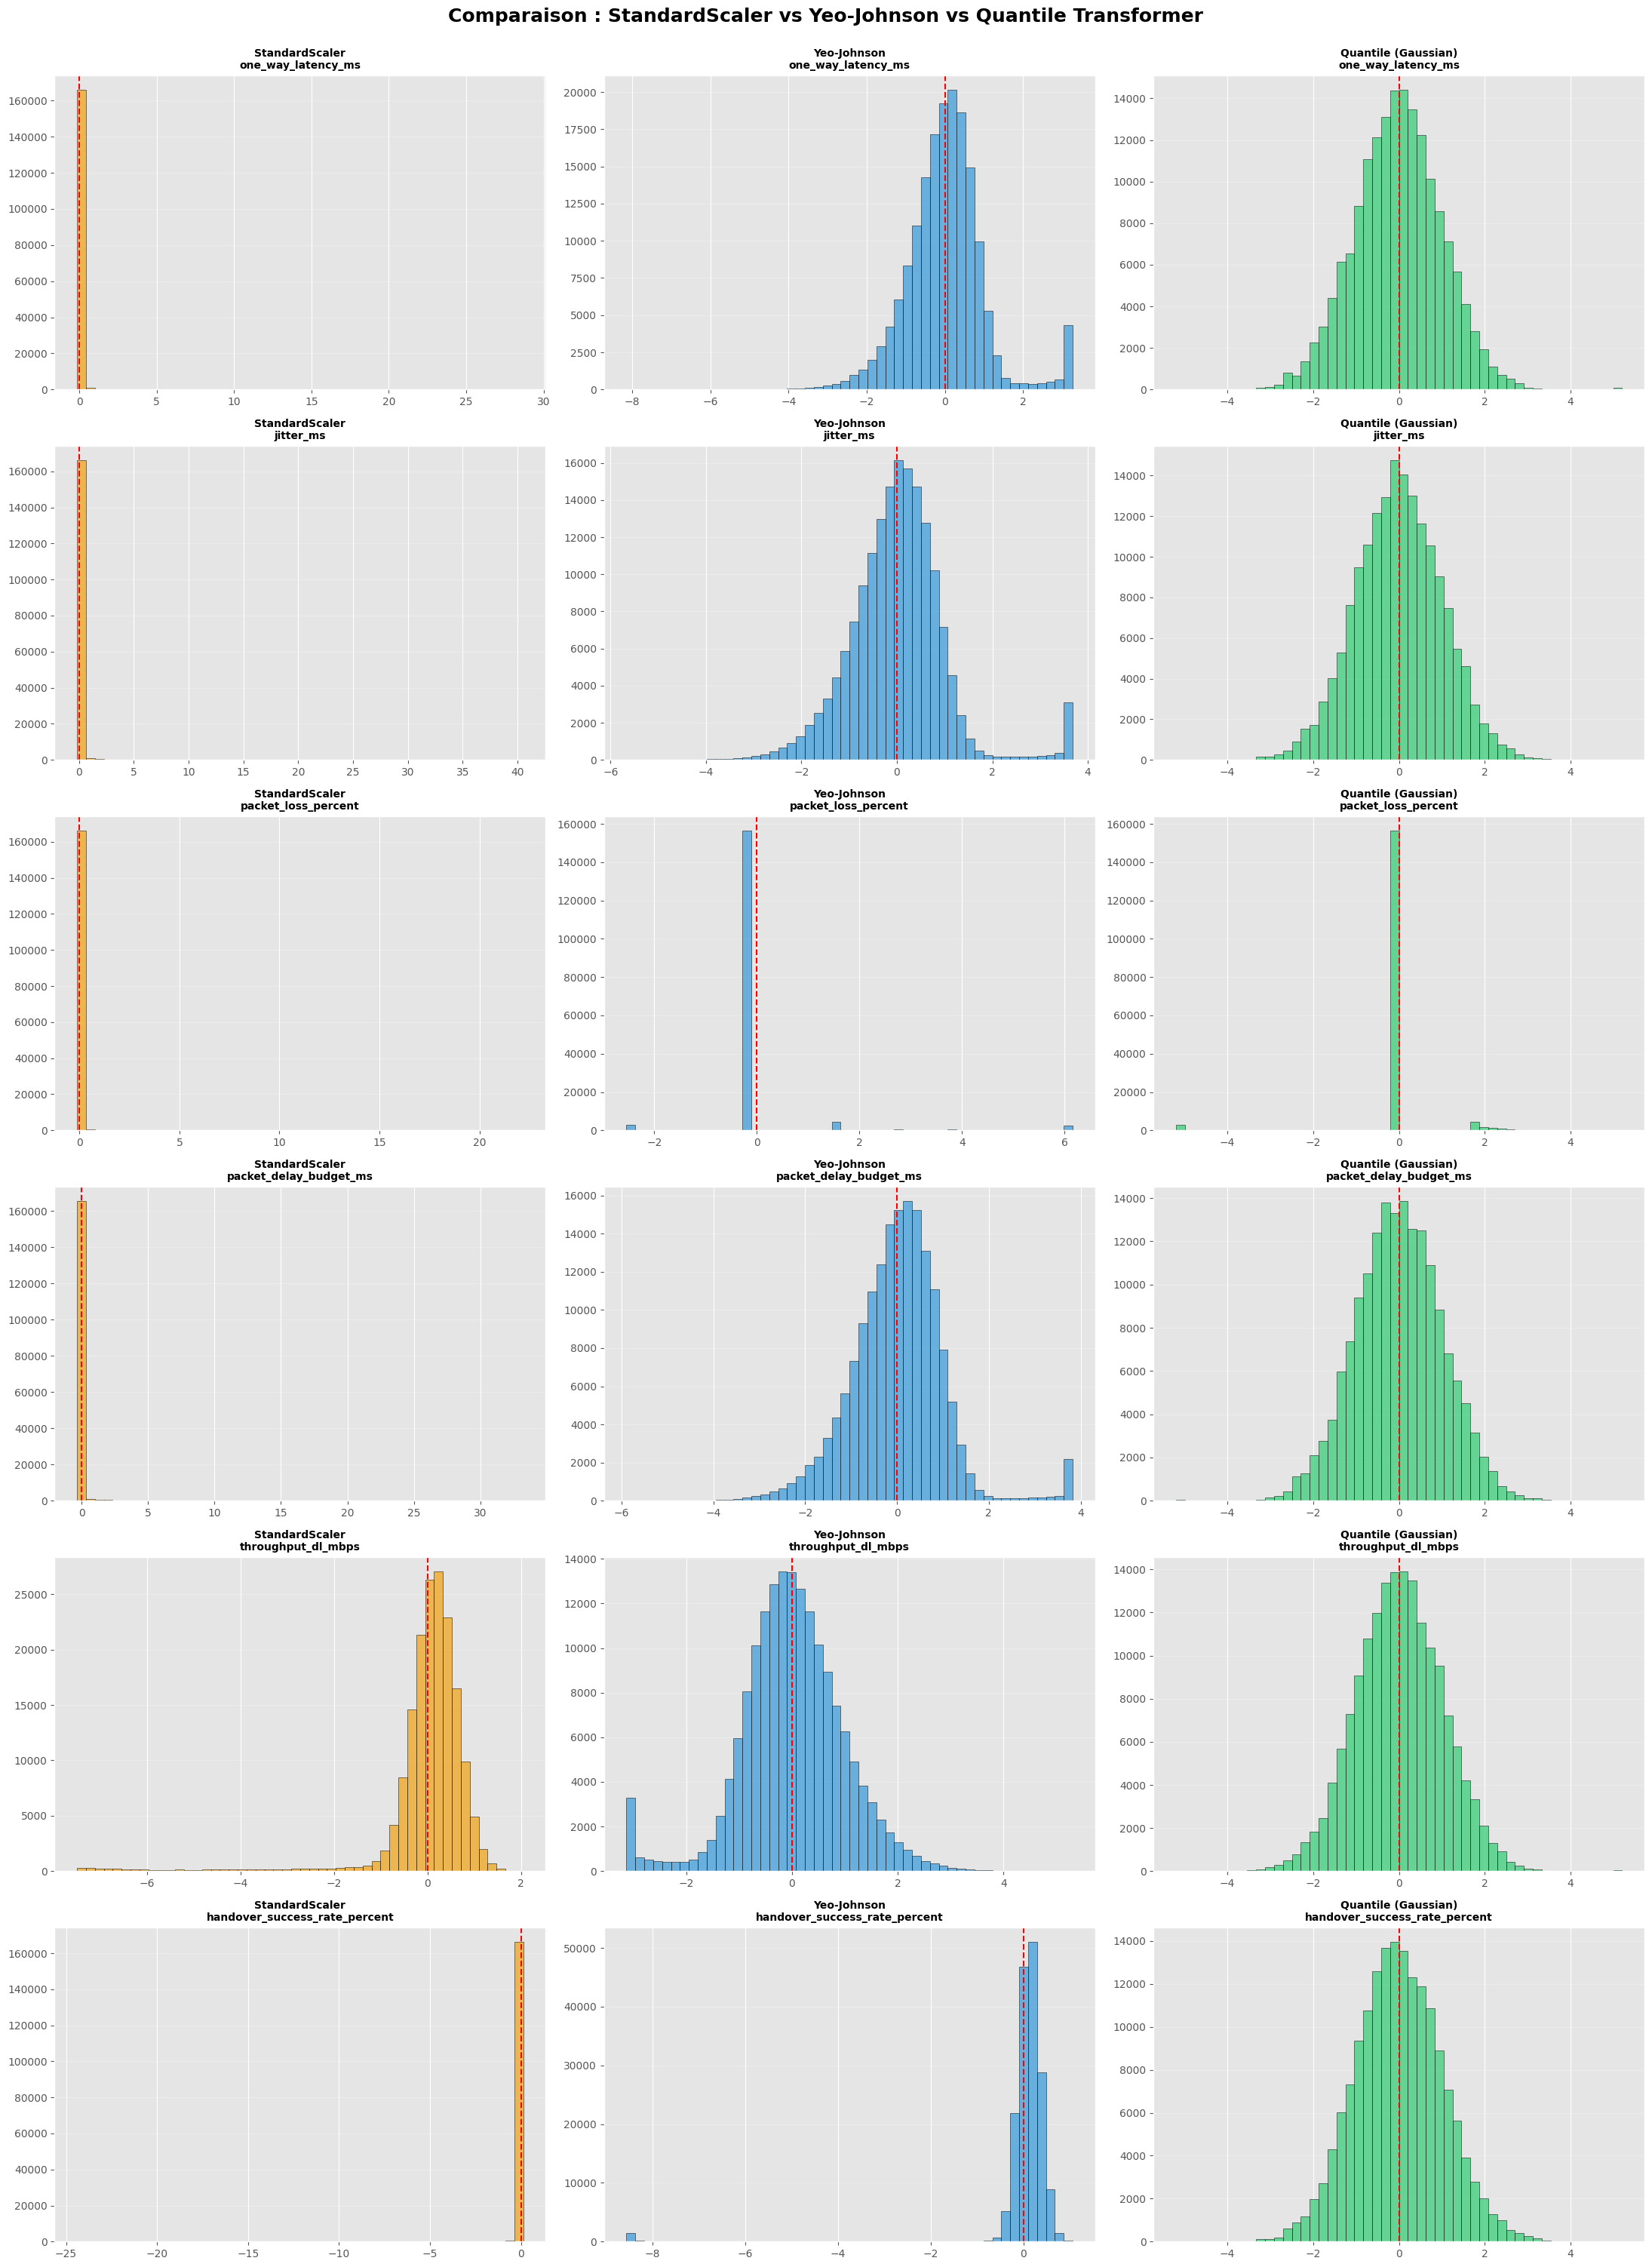

SHAPIRO-WILK COMPARISON (sample=5000)

Feature                                   StandardScaler     Yeo-Johnson        Quantile
---------------------------------------------------------------------------------------
slice_type                                      1.0000 *        1.0000 *        1.0000 *
latitude                                        0.9997        0.9997        0.9998 *
longitude                                       0.9997 *        0.9997        0.9992
one_way_latency_ms                              0.0629        0.9395        0.9989 *
jitter_ms                                       0.0699        0.9345        0.9996 *
packet_delay_budget_ms                          0.0818        0.9483        0.9992 *
handover_interruption_time_ms                   0.0348        0.9618        0.9994 *
packet_loss_percent                             0.0648        0.2966        0.3132 *
throughput_dl_mbps                              0.5965        0.9711        0.9990 *
handover_succes

In [32]:
# =====================================================================
# 5.bis.2 Visual Comparison: StandardScaler vs Yeo-Johnson vs Quantile
# =====================================================================
# Select 6 representative features available in the current dataset
features_to_compare = [
    'one_way_latency_ms', 'jitter_ms', 'packet_loss_percent',
    'packet_delay_budget_ms', 'throughput_dl_mbps', 'handover_success_rate_percent'
]

fig, axes = plt.subplots(len(features_to_compare), 3, figsize=(22, 5 * len(features_to_compare)))

for row, feat in enumerate(features_to_compare):
    # Column 1: StandardScaler
    axes[row, 0].hist(X_train_b_scaled[feat], bins=50, color="#f0a10f", alpha=0.7, edgecolor='black')
    axes[row, 0].set_title(f'StandardScaler\n{feat}', fontsize=10, fontweight='bold')
    axes[row, 0].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[row, 0].grid(axis='y', alpha=0.3)

    # Column 2: Yeo-Johnson
    axes[row, 1].hist(X_train_b_yeojohnson[feat], bins=50, color="#3498db", alpha=0.7, edgecolor='black')
    axes[row, 1].set_title(f'Yeo-Johnson\n{feat}', fontsize=10, fontweight='bold')
    axes[row, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[row, 1].grid(axis='y', alpha=0.3)

    # Column 3: Quantile Transformer
    axes[row, 2].hist(X_train_b_quantile[feat], bins=50, color="#2ecc71", alpha=0.7, edgecolor='black')
    axes[row, 2].set_title(f'Quantile (Gaussian)\n{feat}', fontsize=10, fontweight='bold')
    axes[row, 2].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[row, 2].grid(axis='y', alpha=0.3)

plt.suptitle('Comparaison : StandardScaler vs Yeo-Johnson vs Quantile Transformer',
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# =====================================================================
# Shapiro-Wilk comparison on a sample
# =====================================================================
from scipy import stats

print("="*80)
print("SHAPIRO-WILK COMPARISON (sample=5000)")
print("="*80)
print(f"\n{'Feature':<40} {'StandardScaler':>15} {'Yeo-Johnson':>15} {'Quantile':>15}")
print("-" * 87)

sample_size = 5000
for feat in X_train_b_scaled.columns:
    w_std, _ = stats.shapiro(X_train_b_scaled[feat].sample(sample_size, random_state=42))
    w_yj, _ = stats.shapiro(X_train_b_yeojohnson[feat].sample(sample_size, random_state=42))
    w_qt, _ = stats.shapiro(X_train_b_quantile[feat].sample(sample_size, random_state=42))
    
    # Mark the best W statistic (closest to 1)
    best = max(w_std, w_yj, w_qt)
    mark_std = " *" if w_std == best else ""
    mark_yj = " *" if w_yj == best else ""
    mark_qt = " *" if w_qt == best else ""
    
    print(f"{feat:<40} {w_std:>13.4f}{mark_std} {w_yj:>13.4f}{mark_yj} {w_qt:>13.4f}{mark_qt}")

print("\n* = best W statistic (closest to 1 = most normal)")
print("\nConclusion:")
print("   Yeo-Johnson: recommended for most ML models (natural normalization)")
print("   Quantile: forces perfect Gaussian but may distort feature relationships")

# =====================================================================
# MODELISATION with QUANTILE TRANSFORMER
# =====================================================================
Après comparaison, nous utilisons le **QuantileTransformer (Gaussian)** pour normaliser les features avant l'entraînement des modèles. Cette approche force une distribution normale parfaite sur chaque feature.

## Step 6: QuantileTransformer — Préparation des jeux de données

In [33]:
# =====================================================================
# 6.1 Apply QuantileTransformer to Binary Classification Sets
# =====================================================================
from sklearn.preprocessing import QuantileTransformer

# Fit on training data ONLY, then transform both train and test
qt_binary = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)

X_train_b_qt = pd.DataFrame(
    qt_binary.fit_transform(X_train_b),
    columns=X_train_b.columns,
    index=X_train_b.index
)
X_test_b_qt = pd.DataFrame(
    qt_binary.transform(X_test_b),
    columns=X_test_b.columns,
    index=X_test_b.index
)

# =====================================================================
# 6.2 Apply QuantileTransformer to Multi-class Classification Sets
# =====================================================================
qt_multi = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)

X_train_m_qt = pd.DataFrame(
    qt_multi.fit_transform(X_train_m),
    columns=X_train_m.columns,
    index=X_train_m.index
)
X_test_m_qt = pd.DataFrame(
    qt_multi.transform(X_test_m),
    columns=X_test_m.columns,
    index=X_test_m.index
)

# =====================================================================
# 6.3 Verification
# =====================================================================
print("="*70)
print("QUANTILE TRANSFORMER - DATASETS READY")
print("="*70)

print("\n--- Binary Classification ---")
print(f"  X_train_b_qt: {X_train_b_qt.shape}")
print(f"  X_test_b_qt:  {X_test_b_qt.shape}")
print(f"  Train mean range: [{X_train_b_qt.mean().min():.4f}, {X_train_b_qt.mean().max():.4f}]")
print(f"  Train std range:  [{X_train_b_qt.std().min():.4f}, {X_train_b_qt.std().max():.4f}]")

print("\n--- Multi-class Classification ---")
print(f"  X_train_m_qt: {X_train_m_qt.shape}")
print(f"  X_test_m_qt:  {X_test_m_qt.shape}")
print(f"  Train mean range: [{X_train_m_qt.mean().min():.4f}, {X_train_m_qt.mean().max():.4f}]")
print(f"  Train std range:  [{X_train_m_qt.std().min():.4f}, {X_train_m_qt.std().max():.4f}]")

print("\nPreview (X_train_b_qt):")
X_train_b_qt.head()

QUANTILE TRANSFORMER - DATASETS READY

--- Binary Classification ---
  X_train_b_qt: (168422, 16)
  X_test_b_qt:  (42106, 16)
  Train mean range: [-5.1993, 0.0118]
  Train std range:  [0.0000, 5.1994]

--- Multi-class Classification ---
  X_train_m_qt: (168422, 16)
  X_test_m_qt:  (42106, 16)
  Train mean range: [-5.1993, 0.0126]
  Train std range:  [0.0000, 5.1994]

Preview (X_train_b_qt):


,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,packet_delay_budget_ms,handover_interruption_time_ms,packet_loss_percent,throughput_dl_mbps,handover_success_rate_percent,year,month,day,hour,minute,second
38000,-5.199338,-2.316873,0.479119,0.522099,-0.170185,-0.702315,0.955251,-0.047692,-0.149373,1.887753,-5.199338,-0.340163,-0.384375,1.550085,0.552537,-5.199338
66803,-5.199338,-0.344060,1.025761,0.790155,-0.142244,0.217488,0.110021,-0.047692,-0.251869,-0.849655,-5.199338,0.292676,0.292676,1.550085,5.199338,-5.199338
5081,-5.199338,-0.964181,1.083431,0.958305,1.649002,-2.417279,1.177852,-0.047692,-0.525522,0.959440,-5.199338,-5.199338,0.207223,0.385726,-0.111890,-5.199338
107831,-5.199338,-1.200444,0.496234,-0.976979,-0.392492,-0.217488,1.756704,-0.047692,0.937461,0.385726,5.199338,-5.199338,-0.570161,-0.271787,5.199338,-5.199338
129005,-5.199338,0.456412,0.689679,-0.276856,0.573115,0.912774,0.185115,-0.047692,0.716406,-0.772563,5.199338,-0.830234,0.650274,1.550085,-0.111890,-5.199338


# =====================================================================
# MODÈLE BASELINE — Random Forest (Paramètres par défaut)
# =====================================================================
Évaluation du modèle **Random Forest** avec ses **paramètres par défaut** (sans optimisation) pour établir une référence de performance avant le tuning avec GridSearchCV.

Les données sont transformées par **QuantileTransformer (Gaussian)**.

## 7.0 Baseline — Classification Binaire (Normal vs Anomaly)

RANDOM FOREST BASELINE — CLASSIFICATION BINAIRE (Quantile Transformer)

Paramètres par défaut:
   n_estimators:      100
   criterion:         gini
   max_depth:         None
   min_samples_split: 2
   min_samples_leaf:  1
   max_features:      sqrt

✅ Entraînement terminé en 43.44s

RÉSULTATS BASELINE — Classification Binaire (Quantile Transformer)

  Accuracy:  0.9968
  Precision: 1.0000
  Recall:    0.8466
  F1-Score:  0.9169
  ROC-AUC:   0.9462

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     41226
     Anomaly       1.00      0.85      0.92       880

    accuracy                           1.00     42106
   macro avg       1.00      0.92      0.96     42106
weighted avg       1.00      1.00      1.00     42106



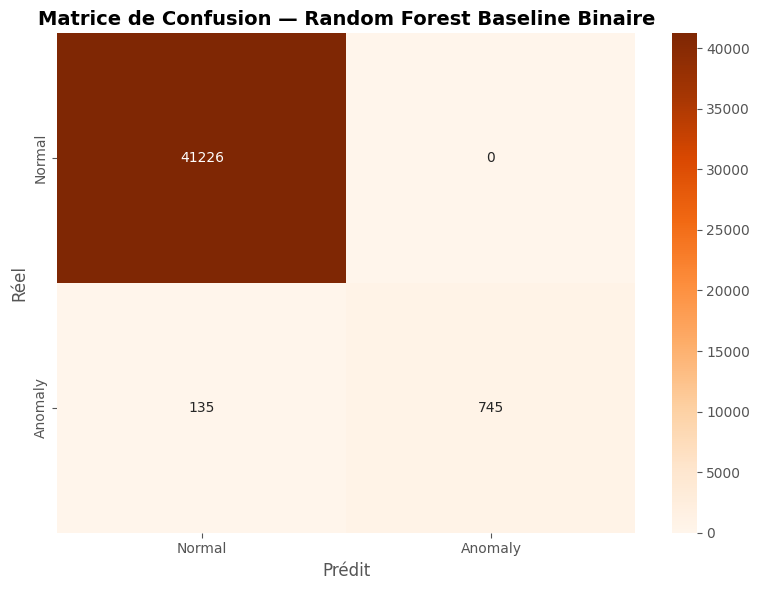

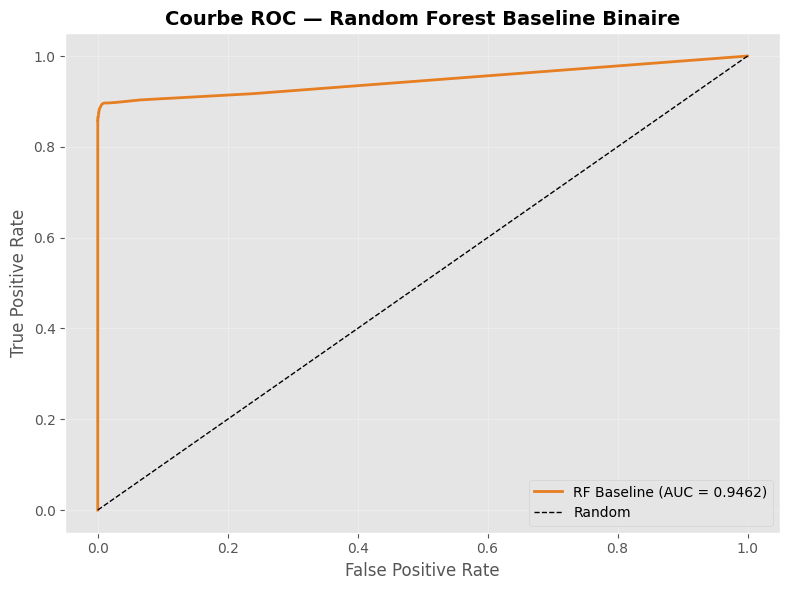

In [34]:
# =====================================================================
# 7.0.1 Random Forest Baseline — Classification Binaire — SANS GridSearch
# =====================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import time

# --- Modèle Baseline avec paramètres par défaut ---
print("="*70)
print("RANDOM FOREST BASELINE — CLASSIFICATION BINAIRE (Quantile Transformer)")
print("="*70)

rf_baseline_b = RandomForestClassifier(random_state=42)

print(f"\nParamètres par défaut:")
print(f"   n_estimators:      {rf_baseline_b.n_estimators}")
print(f"   criterion:         {rf_baseline_b.criterion}")
print(f"   max_depth:         {rf_baseline_b.max_depth}")
print(f"   min_samples_split: {rf_baseline_b.min_samples_split}")
print(f"   min_samples_leaf:  {rf_baseline_b.min_samples_leaf}")
print(f"   max_features:      {rf_baseline_b.max_features}")

# --- Entraînement ---
start_time = time.time()
rf_baseline_b.fit(X_train_b_qt, y1_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y1_pred_baseline = rf_baseline_b.predict(X_test_b_qt)
y1_proba_baseline = rf_baseline_b.predict_proba(X_test_b_qt)[:, 1]

# --- Métriques d'évaluation ---
acc_baseline = accuracy_score(y1_test, y1_pred_baseline)
prec_baseline = precision_score(y1_test, y1_pred_baseline)
rec_baseline = recall_score(y1_test, y1_pred_baseline)
f1_baseline = f1_score(y1_test, y1_pred_baseline)
auc_baseline = roc_auc_score(y1_test, y1_proba_baseline)

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Binaire (Quantile Transformer)")
print("="*70)
print(f"\n  Accuracy:  {acc_baseline:.4f}")
print(f"  Precision: {prec_baseline:.4f}")
print(f"  Recall:    {rec_baseline:.4f}")
print(f"  F1-Score:  {f1_baseline:.4f}")
print(f"  ROC-AUC:   {auc_baseline:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y1_test, y1_pred_baseline, target_names=['Normal', 'Anomaly']))

# --- Matrice de confusion ---
cm_baseline = confusion_matrix(y1_test, y1_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Matrice de Confusion — Random Forest Baseline Binaire', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

# --- Courbe ROC ---
fpr_bl, tpr_bl, _ = roc_curve(y1_test, y1_proba_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bl, tpr_bl, color='#e67e22', linewidth=2, label=f'RF Baseline (AUC = {auc_baseline:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — Random Forest Baseline Binaire', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7.0 Baseline — Classification Multi-classes (Types d'anomalies)

RANDOM FOREST BASELINE — CLASSIFICATION MULTI-CLASSES (Quantile Transformer)

Paramètres par défaut:
   n_estimators:      100
   criterion:         gini
   max_depth:         None
   min_samples_split: 2
   min_samples_leaf:  1

✅ Entraînement terminé en 46.29s

RÉSULTATS BASELINE — Classification Multi-classes (Quantile Transformer)

  Accuracy:           0.9963
  Precision (weighted): 0.9962
  Recall (weighted):    0.9963
  F1-Score (weighted):  0.9961

📊 Classification Report:
                    precision    recall  f1-score   support

    backhaul_issue       1.00      0.87      0.93       126
  handover_failure       1.00      0.88      0.94       116
  hardware_failure       0.98      0.79      0.87       100
      interference       1.00      0.86      0.93       111
network_congestion       0.99      0.87      0.93        95
            normal       1.00      1.00      1.00     41226
          overload       0.88      0.72      0.79       104
   security_attack       1.00    

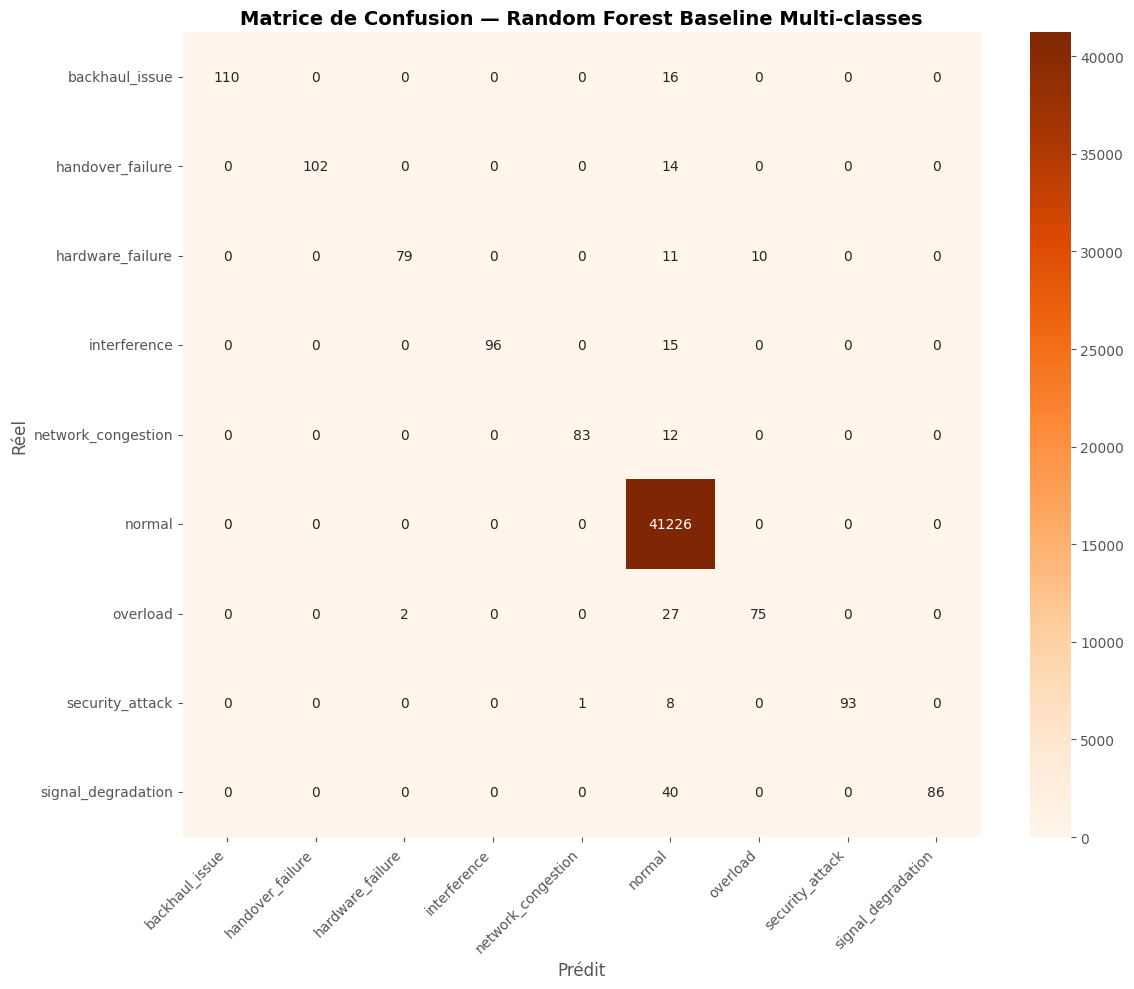


📋 RÉSUMÉ BASELINE RANDOM FOREST (Paramètres par défaut)

  Métrique                     Binaire   Multi-classes
  --------------------------------------------------
  Accuracy                      0.9968          0.9963
  Precision                     1.0000          0.9962
  Recall                        0.8466          0.9963
  F1-Score                      0.9169          0.9961

⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration
   apportée par l'optimisation des hyperparamètres (GridSearchCV).


In [35]:
# =====================================================================
# 7.0.2 Random Forest Baseline — Classification Multi-classes — SANS GridSearch
# =====================================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import time

# --- Modèle Baseline Multi-classes avec paramètres par défaut ---
print("="*70)
print("RANDOM FOREST BASELINE — CLASSIFICATION MULTI-CLASSES (Quantile Transformer)")
print("="*70)

rf_baseline_m = RandomForestClassifier(random_state=42)

print(f"\nParamètres par défaut:")
print(f"   n_estimators:      {rf_baseline_m.n_estimators}")
print(f"   criterion:         {rf_baseline_m.criterion}")
print(f"   max_depth:         {rf_baseline_m.max_depth}")
print(f"   min_samples_split: {rf_baseline_m.min_samples_split}")
print(f"   min_samples_leaf:  {rf_baseline_m.min_samples_leaf}")

# --- Entraînement ---
start_time = time.time()
rf_baseline_m.fit(X_train_m_qt, y2_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y2_pred_baseline = rf_baseline_m.predict(X_test_m_qt)

# --- Métriques d'évaluation ---
acc_baseline_m = accuracy_score(y2_test, y2_pred_baseline)
prec_baseline_m = precision_score(y2_test, y2_pred_baseline, average='weighted')
rec_baseline_m = recall_score(y2_test, y2_pred_baseline, average='weighted')
f1_baseline_m = f1_score(y2_test, y2_pred_baseline, average='weighted')

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Multi-classes (Quantile Transformer)")
print("="*70)
print(f"\n  Accuracy:           {acc_baseline_m:.4f}")
print(f"  Precision (weighted): {prec_baseline_m:.4f}")
print(f"  Recall (weighted):    {rec_baseline_m:.4f}")
print(f"  F1-Score (weighted):  {f1_baseline_m:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y2_test, y2_pred_baseline, target_names=le_anomaly.classes_))

# --- Matrice de confusion ---
cm_baseline_m = confusion_matrix(y2_test, y2_pred_baseline)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_baseline_m, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_anomaly.classes_,
            yticklabels=le_anomaly.classes_)
plt.title('Matrice de Confusion — Random Forest Baseline Multi-classes', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Résumé Baseline ---
print(f"\n{'='*70}")
print("📋 RÉSUMÉ BASELINE RANDOM FOREST (Paramètres par défaut)")
print("="*70)
print(f"\n  {'Métrique':<25} {'Binaire':>10} {'Multi-classes':>15}")
print(f"  {'-'*50}")
print(f"  {'Accuracy':<25} {acc_baseline:>10.4f} {acc_baseline_m:>15.4f}")
print(f"  {'Precision':<25} {prec_baseline:>10.4f} {prec_baseline_m:>15.4f}")
print(f"  {'Recall':<25} {rec_baseline:>10.4f} {rec_baseline_m:>15.4f}")
print(f"  {'F1-Score':<25} {f1_baseline:>10.4f} {f1_baseline_m:>15.4f}")
print(f"\n⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration")
print(f"   apportée par l'optimisation des hyperparamètres (GridSearchCV).")

## 7. Modélisation — Classification Binaire 


## 8. Optimisation des Modèles (Random Forest)

On optimise d'abord le baseline avec `RandomizedSearchCV` pour la classification binaire et multi-classes, puis on compare les performances avec le baseline.

In [36]:
# =====================================================================
# 8.1 Random Forest optimisé - Binaire + Multi-classes
# =====================================================================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

param_dist_rf = {
    'n_estimators': [150, 250, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.8],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

print('=' * 80)
print('OPTIMISATION RANDOM FOREST - CLASSIFICATION BINAIRE')
print('=' * 80)

rf_search_b = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
rf_search_b.fit(X_train_b_qt, y1_train)
search_time_b = time.time() - start_time

best_rf_b = rf_search_b.best_estimator_
print(f"\nMeilleurs paramètres (binaire): {rf_search_b.best_params_}")
print(f"Meilleur score CV F1 (binaire): {rf_search_b.best_score_:.4f}")
print(f"Temps de recherche: {search_time_b:.2f}s")

y1_train_pred_opt = best_rf_b.predict(X_train_b_qt)
y1_test_pred_opt = best_rf_b.predict(X_test_b_qt)
y1_test_proba_opt = best_rf_b.predict_proba(X_test_b_qt)[:, 1]

acc_opt_b = accuracy_score(y1_test, y1_test_pred_opt)
prec_opt_b = precision_score(y1_test, y1_test_pred_opt)
rec_opt_b = recall_score(y1_test, y1_test_pred_opt)
f1_opt_b = f1_score(y1_test, y1_test_pred_opt)
auc_opt_b = roc_auc_score(y1_test, y1_test_proba_opt)

print('\nRésultats test - RF optimisé (binaire):')
print(f"  Accuracy:  {acc_opt_b:.4f}")
print(f"  Precision: {prec_opt_b:.4f}")
print(f"  Recall:    {rec_opt_b:.4f}")
print(f"  F1-Score:  {f1_opt_b:.4f}")
print(f"  ROC-AUC:   {auc_opt_b:.4f}")

print('\n' + '=' * 80)
print('OPTIMISATION RANDOM FOREST - CLASSIFICATION MULTI-CLASSES')
print('=' * 80)

rf_search_m = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=15,
    scoring='f1_weighted',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
rf_search_m.fit(X_train_m_qt, y2_train)
search_time_m = time.time() - start_time

best_rf_m = rf_search_m.best_estimator_
print(f"\nMeilleurs paramètres (multi): {rf_search_m.best_params_}")
print(f"Meilleur score CV F1-weighted (multi): {rf_search_m.best_score_:.4f}")
print(f"Temps de recherche: {search_time_m:.2f}s")

y2_train_pred_opt = best_rf_m.predict(X_train_m_qt)
y2_test_pred_opt = best_rf_m.predict(X_test_m_qt)

acc_opt_m = accuracy_score(y2_test, y2_test_pred_opt)
prec_opt_m = precision_score(y2_test, y2_test_pred_opt, average='weighted')
rec_opt_m = recall_score(y2_test, y2_test_pred_opt, average='weighted')
f1_opt_m = f1_score(y2_test, y2_test_pred_opt, average='weighted')

print('\nRésultats test - RF optimisé (multi):')
print(f"  Accuracy:            {acc_opt_m:.4f}")
print(f"  Precision weighted:  {prec_opt_m:.4f}")
print(f"  Recall weighted:     {rec_opt_m:.4f}")
print(f"  F1-Score weighted:   {f1_opt_m:.4f}")

OPTIMISATION RANDOM FOREST - CLASSIFICATION BINAIRE
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Meilleurs paramètres (binaire): {'n_estimators': 250, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': None, 'class_weight': None}
Meilleur score CV F1 (binaire): 0.9082
Temps de recherche: 1499.42s

Résultats test - RF optimisé (binaire):
  Accuracy:  0.9969
  Precision: 0.9987
  Recall:    0.8523
  F1-Score:  0.9197
  ROC-AUC:   0.9461

OPTIMISATION RANDOM FOREST - CLASSIFICATION MULTI-CLASSES
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Meilleurs paramètres (multi): {'n_estimators': 250, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': None, 'class_weight': None}
Meilleur score CV F1-weighted (multi): 0.9959
Temps de recherche: 1341.00s

Résultats test - RF optimisé (multi):
  Accuracy:            0.9963
  Precision weighted:  0.9962
  Recall weighted:     0.9963
  F1-Score weighted:   0.9

CONTROLE OVERFITTING
              Task  F1 Train  F1 Test  Gap (Train-Test)
Binaire - Baseline  0.999858 0.916923          0.082935
Binaire - Optimisé  0.923242 0.919681          0.003560
  Multi - Baseline  0.999994 0.996082          0.003912
  Multi - Optimisé  0.996921 0.996076          0.000844

Cross-validation (modèles optimisés):
  Binaire  - CV F1 mean: 0.9082 (+/- 0.0054)
  Multi    - CV F1 mean: 0.9959 (+/- 0.0001)


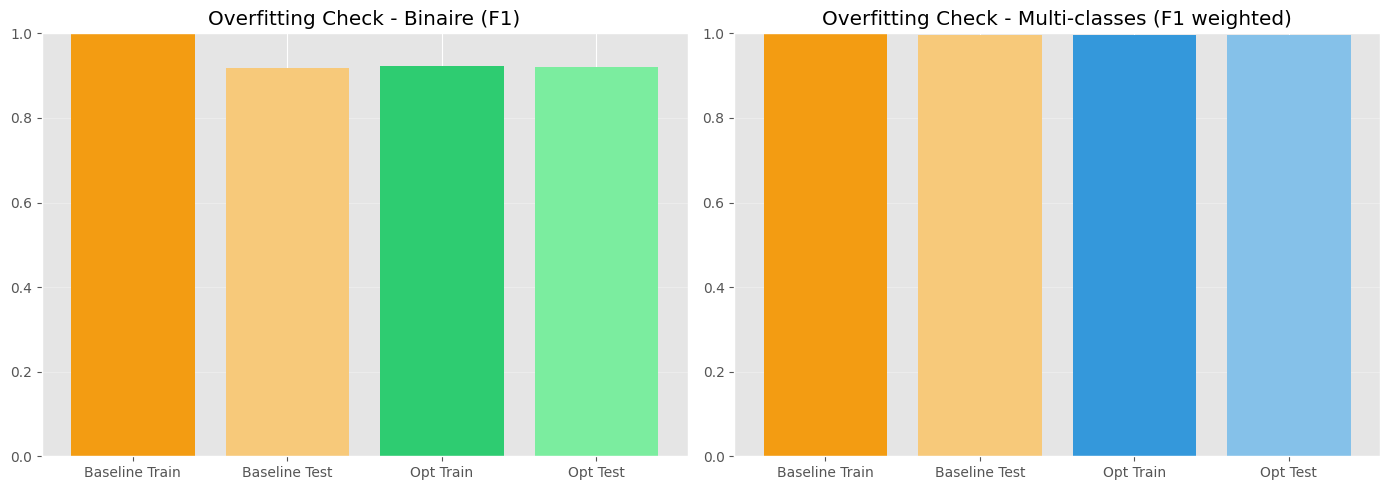

In [37]:
# =====================================================================
# 8.2 Contrôle de l'overfitting (Train vs Test + Cross-Validation)
# =====================================================================
from sklearn.model_selection import cross_val_score

# Baseline train predictions (pour mesurer l'écart train-test)
y1_train_pred_baseline = rf_baseline_b.predict(X_train_b_qt)
y2_train_pred_baseline = rf_baseline_m.predict(X_train_m_qt)

# Scores train/test
f1_train_baseline_b = f1_score(y1_train, y1_train_pred_baseline)
f1_test_baseline_b = f1_score(y1_test, y1_pred_baseline)
f1_train_opt_b = f1_score(y1_train, y1_train_pred_opt)
f1_test_opt_b = f1_score(y1_test, y1_test_pred_opt)

f1_train_baseline_m = f1_score(y2_train, y2_train_pred_baseline, average='weighted')
f1_test_baseline_m = f1_score(y2_test, y2_pred_baseline, average='weighted')
f1_train_opt_m = f1_score(y2_train, y2_train_pred_opt, average='weighted')
f1_test_opt_m = f1_score(y2_test, y2_test_pred_opt, average='weighted')

# Validation croisée pour robustesse
cv_f1_b = cross_val_score(best_rf_b, X_train_b_qt, y1_train, cv=3, scoring='f1', n_jobs=-1)
cv_f1_m = cross_val_score(best_rf_m, X_train_m_qt, y2_train, cv=3, scoring='f1_weighted', n_jobs=-1)

overfit_summary = pd.DataFrame([
    {
        'Task': 'Binaire - Baseline',
        'F1 Train': f1_train_baseline_b,
        'F1 Test': f1_test_baseline_b,
        'Gap (Train-Test)': f1_train_baseline_b - f1_test_baseline_b
    },
    {
        'Task': 'Binaire - Optimisé',
        'F1 Train': f1_train_opt_b,
        'F1 Test': f1_test_opt_b,
        'Gap (Train-Test)': f1_train_opt_b - f1_test_opt_b
    },
    {
        'Task': 'Multi - Baseline',
        'F1 Train': f1_train_baseline_m,
        'F1 Test': f1_test_baseline_m,
        'Gap (Train-Test)': f1_train_baseline_m - f1_test_baseline_m
    },
    {
        'Task': 'Multi - Optimisé',
        'F1 Train': f1_train_opt_m,
        'F1 Test': f1_test_opt_m,
        'Gap (Train-Test)': f1_train_opt_m - f1_test_opt_m
    }
])

print('=' * 80)
print('CONTROLE OVERFITTING')
print('=' * 80)
print(overfit_summary.to_string(index=False))

print('\nCross-validation (modèles optimisés):')
print(f"  Binaire  - CV F1 mean: {cv_f1_b.mean():.4f} (+/- {cv_f1_b.std():.4f})")
print(f"  Multi    - CV F1 mean: {cv_f1_m.mean():.4f} (+/- {cv_f1_m.std():.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binaire
axes[0].bar(['Baseline Train', 'Baseline Test', 'Opt Train', 'Opt Test'],
            [f1_train_baseline_b, f1_test_baseline_b, f1_train_opt_b, f1_test_opt_b],
            color=['#f39c12', '#f7c97a', '#2ecc71', '#7bed9f'])
axes[0].set_title('Overfitting Check - Binaire (F1)')
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# Multi
axes[1].bar(['Baseline Train', 'Baseline Test', 'Opt Train', 'Opt Test'],
            [f1_train_baseline_m, f1_test_baseline_m, f1_train_opt_m, f1_test_opt_m],
            color=['#f39c12', '#f7c97a', '#3498db', '#85c1e9'])
axes[1].set_title('Overfitting Check - Multi-classes (F1 weighted)')
axes[1].set_ylim(0, 1.0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

COMPARAISON RANDOM FOREST - CLASSIFICATION BINAIRE
                Modèle  Accuracy  Precision   Recall       F1  ROC-AUC
Random Forest Baseline  0.996794   1.000000 0.846591 0.916923 0.946172
Random Forest Optimisé  0.996889   0.998668 0.852273 0.919681 0.946143


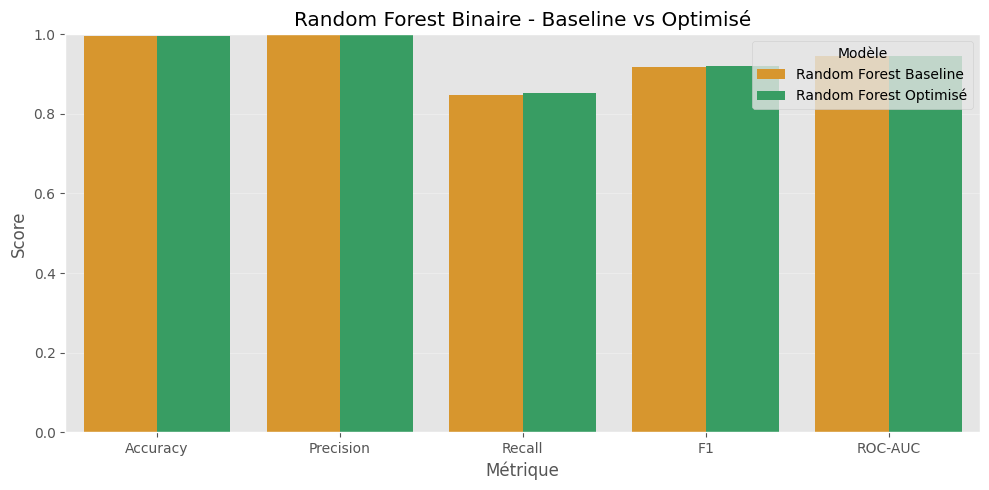

In [38]:
# =====================================================================
# 8.3 Comparaison Random Forest - Classification Binaire
# =====================================================================
binary_results_df = pd.DataFrame([
    {
        'Modèle': 'Random Forest Baseline',
        'Accuracy': acc_baseline,
        'Precision': prec_baseline,
        'Recall': rec_baseline,
        'F1': f1_baseline,
        'ROC-AUC': auc_baseline
    },
    {
        'Modèle': 'Random Forest Optimisé',
        'Accuracy': acc_opt_b,
        'Precision': prec_opt_b,
        'Recall': rec_opt_b,
        'F1': f1_opt_b,
        'ROC-AUC': auc_opt_b
    }
])

print('=' * 90)
print('COMPARAISON RANDOM FOREST - CLASSIFICATION BINAIRE')
print('=' * 90)
print(binary_results_df.to_string(index=False))

plt.figure(figsize=(10, 5))
comparison_binary_plot = binary_results_df.melt(
    id_vars='Modèle',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    var_name='Métrique',
    value_name='Score'
)
sns.barplot(data=comparison_binary_plot, x='Métrique', y='Score', hue='Modèle', palette=['#f39c12', '#27ae60'])
plt.title('Random Forest Binaire - Baseline vs Optimisé')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

COMPARAISON RANDOM FOREST - MULTI-CLASSES
                Modèle  Accuracy  Precision weighted  Recall weighted  F1 weighted
Random Forest Baseline  0.996295            0.996239         0.996295     0.996082
Random Forest Optimisé  0.996295            0.996213         0.996295     0.996076


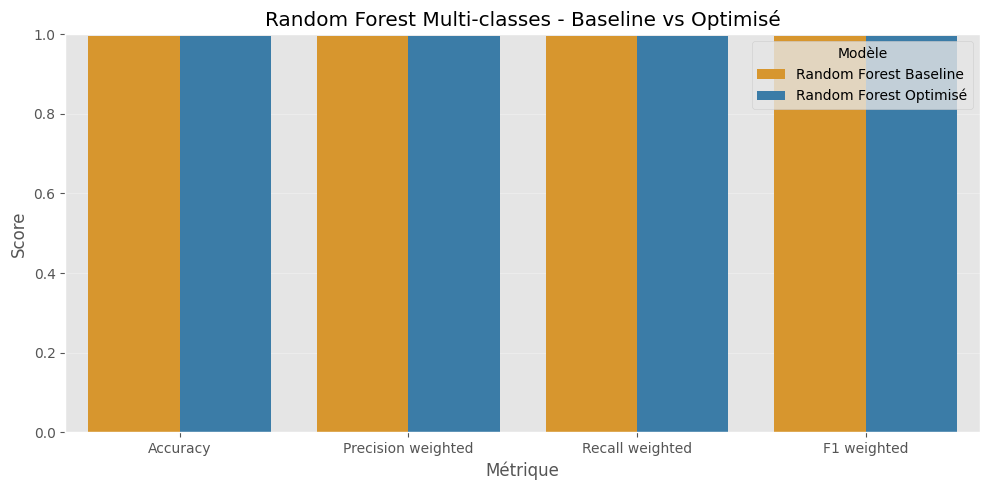


RÉSUMÉ FINAL - RANDOM FOREST

Classification binaire:
  Accuracy : 0.9968 -> 0.9969  | gain = +0.0001
  Precision: 1.0000 -> 0.9987 | gain = -0.0013
  Recall   : 0.8466 -> 0.8523  | gain = +0.0057
  F1-Score : 0.9169 -> 0.9197   | gain = +0.0028
  ROC-AUC  : 0.9462 -> 0.9461  | gain = -0.0000

Classification multi-classes:
  Accuracy          : 0.9963 -> 0.9963 | gain = +0.0000
  Precision weighted: 0.9962 -> 0.9962 | gain = -0.0000
  Recall weighted   : 0.9963 -> 0.9963 | gain = +0.0000
  F1 weighted       : 0.9961 -> 0.9961 | gain = -0.0000

Contrôle overfitting (gap train-test):
              Task  Gap (Train-Test)
Binaire - Baseline          0.082935
Binaire - Optimisé          0.003560
  Multi - Baseline          0.003912
  Multi - Optimisé          0.000844


In [39]:
# =====================================================================
# 8.4 Comparaison Random Forest - Multi-classes
# =====================================================================
multi_results_df = pd.DataFrame([
    {
        'Modèle': 'Random Forest Baseline',
        'Accuracy': acc_baseline_m,
        'Precision weighted': prec_baseline_m,
        'Recall weighted': rec_baseline_m,
        'F1 weighted': f1_baseline_m
    },
    {
        'Modèle': 'Random Forest Optimisé',
        'Accuracy': acc_opt_m,
        'Precision weighted': prec_opt_m,
        'Recall weighted': rec_opt_m,
        'F1 weighted': f1_opt_m
    }
])

print('=' * 90)
print('COMPARAISON RANDOM FOREST - MULTI-CLASSES')
print('=' * 90)
print(multi_results_df.to_string(index=False))

plt.figure(figsize=(10, 5))
comparison_multi_plot = multi_results_df.melt(
    id_vars='Modèle',
    value_vars=['Accuracy', 'Precision weighted', 'Recall weighted', 'F1 weighted'],
    var_name='Métrique',
    value_name='Score'
)
sns.barplot(data=comparison_multi_plot, x='Métrique', y='Score', hue='Modèle', palette=['#f39c12', '#2980b9'])
plt.title('Random Forest Multi-classes - Baseline vs Optimisé')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================================
# 8.5 Résumé final - Baseline vs Optimisé uniquement
# =====================================================================
print('\n' + '=' * 90)
print('RÉSUMÉ FINAL - RANDOM FOREST')
print('=' * 90)
print('\nClassification binaire:')
print(f"  Accuracy : {acc_baseline:.4f} -> {acc_opt_b:.4f}  | gain = {acc_opt_b - acc_baseline:+.4f}")
print(f"  Precision: {prec_baseline:.4f} -> {prec_opt_b:.4f} | gain = {prec_opt_b - prec_baseline:+.4f}")
print(f"  Recall   : {rec_baseline:.4f} -> {rec_opt_b:.4f}  | gain = {rec_opt_b - rec_baseline:+.4f}")
print(f"  F1-Score : {f1_baseline:.4f} -> {f1_opt_b:.4f}   | gain = {f1_opt_b - f1_baseline:+.4f}")
print(f"  ROC-AUC  : {auc_baseline:.4f} -> {auc_opt_b:.4f}  | gain = {auc_opt_b - auc_baseline:+.4f}")

print('\nClassification multi-classes:')
print(f"  Accuracy          : {acc_baseline_m:.4f} -> {acc_opt_m:.4f} | gain = {acc_opt_m - acc_baseline_m:+.4f}")
print(f"  Precision weighted: {prec_baseline_m:.4f} -> {prec_opt_m:.4f} | gain = {prec_opt_m - prec_baseline_m:+.4f}")
print(f"  Recall weighted   : {rec_baseline_m:.4f} -> {rec_opt_m:.4f} | gain = {rec_opt_m - rec_baseline_m:+.4f}")
print(f"  F1 weighted       : {f1_baseline_m:.4f} -> {f1_opt_m:.4f} | gain = {f1_opt_m - f1_baseline_m:+.4f}")

print('\nContrôle overfitting (gap train-test):')
print(overfit_summary[['Task', 'Gap (Train-Test)']].to_string(index=False))

In [40]:
# =====================================================================
# 9. Anti-overfitting protocol (diagnostic + corrected evaluation)
# =====================================================================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print('=' * 90)
print('ANTI-OVERFITTING PROTOCOL - RANDOM FOREST (BINAIRE)')
print('=' * 90)

# 9.1 Build a strict modeling table
model_df = df_clean.copy()

# Parse timestamp for chronological split when available
if 'timestamp' in model_df.columns:
    model_df['timestamp_dt'] = pd.to_datetime(model_df['timestamp'], errors='coerce')

# Remove exact duplicates on full row to reduce memorization
rows_before = len(model_df)
model_df = model_df.drop_duplicates().reset_index(drop=True)
rows_after = len(model_df)
print(f'Rows before dedup: {rows_before:,}')
print(f'Rows after dedup : {rows_after:,}')
print(f'Removed duplicates: {rows_before - rows_after:,}')

# Columns likely to act as identifiers / leakage proxies
leak_prone_cols = ['latitude', 'longitude', 'year', 'month', 'day', 'hour', 'minute', 'second']
leak_prone_cols = [c for c in leak_prone_cols if c in model_df.columns]
print(f'Potential leakage columns removed from modeling: {leak_prone_cols}')

# Encode categorical feature if still object
if 'slice_type' in model_df.columns and model_df['slice_type'].dtype == 'object':
    le_slice_local = LabelEncoder()
    model_df['slice_type'] = le_slice_local.fit_transform(model_df['slice_type'])

feature_exclude = ['timestamp', 'timestamp_dt', 'anomaly', 'anomaly_type'] + leak_prone_cols
feature_cols = [c for c in model_df.columns if c not in feature_exclude]

X_strict = model_df[feature_cols].copy()
y_strict = model_df['anomaly'].astype(int).copy()

# 9.2 Strict split: chronological if timestamp exists, otherwise stratified random
if 'timestamp_dt' in model_df.columns and model_df['timestamp_dt'].notna().sum() > 0:
    model_df = model_df.sort_values('timestamp_dt').reset_index(drop=True)
    X_strict = model_df[feature_cols].copy()
    y_strict = model_df['anomaly'].astype(int).copy()

    split_idx = int(0.8 * len(model_df))
    X_train_s, X_test_s = X_strict.iloc[:split_idx], X_strict.iloc[split_idx:]
    y_train_s, y_test_s = y_strict.iloc[:split_idx], y_strict.iloc[split_idx:]
    split_mode = 'Chronological 80/20'
else:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_strict, y_strict, test_size=0.2, random_state=42, stratify=y_strict
    )
    split_mode = 'Stratified random 80/20 (fallback)'

print(f'\nSplit mode: {split_mode}')
print(f'Train shape: {X_train_s.shape} | Test shape: {X_test_s.shape}')
print(f'Train anomaly rate: {y_train_s.mean():.4f} | Test anomaly rate: {y_test_s.mean():.4f}')

# 9.3 Transformer fit ONLY on training data
qt_strict = QuantileTransformer(
    output_distribution='normal',
    n_quantiles=min(1000, max(100, len(X_train_s) // 10)),
    random_state=42
)

X_train_s_qt = pd.DataFrame(
    qt_strict.fit_transform(X_train_s),
    columns=X_train_s.columns,
    index=X_train_s.index
)
X_test_s_qt = pd.DataFrame(
    qt_strict.transform(X_test_s),
    columns=X_test_s.columns,
    index=X_test_s.index
)

# 9.4 Regularized Random Forest (less capacity -> less overfitting)
rf_strict = RandomForestClassifier(
    n_estimators=250,
    max_depth=10,
    min_samples_split=30,
    min_samples_leaf=12,
    max_features='sqrt',
    class_weight='balanced_subsample',
    bootstrap=True,
    max_samples=0.7,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf_strict.fit(X_train_s_qt, y_train_s)

# 9.5 Evaluation
y_train_pred_s = rf_strict.predict(X_train_s_qt)
y_test_pred_s = rf_strict.predict(X_test_s_qt)
y_test_proba_s = rf_strict.predict_proba(X_test_s_qt)[:, 1]

def compute_metrics(y_true, y_pred, y_proba=None):
    out = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }
    if y_proba is not None:
        out['ROC-AUC'] = roc_auc_score(y_true, y_proba)
    return out

m_train = compute_metrics(y_train_s, y_train_pred_s)
m_test = compute_metrics(y_test_s, y_test_pred_s, y_test_proba_s)

print('\n' + '=' * 90)
print('STRICT EVALUATION RESULTS')
print('=' * 90)
print('Train metrics:')
for k, v in m_train.items():
    print(f'  {k:<10}: {v:.4f}')

print('\nTest metrics:')
for k, v in m_test.items():
    print(f'  {k:<10}: {v:.4f}')

f1_gap = m_train['F1'] - m_test['F1']
print(f'\nF1 gap (train - test): {f1_gap:+.4f}')
print(f'OOB score: {rf_strict.oob_score_:.4f}')

# Feature importance (top 10) to inspect suspicious dominant features
importances = pd.Series(rf_strict.feature_importances_, index=X_train_s_qt.columns).sort_values(ascending=False)
print('\nTop 10 feature importances (strict model):')
print(importances.head(10).to_string())

ANTI-OVERFITTING PROTOCOL - RANDOM FOREST (BINAIRE)
Rows before dedup: 210,528
Rows after dedup : 210,528
Removed duplicates: 0
Potential leakage columns removed from modeling: ['latitude', 'longitude', 'year', 'month', 'day', 'hour', 'minute', 'second']

Split mode: Chronological 80/20
Train shape: (168422, 8) | Test shape: (42106, 8)
Train anomaly rate: 0.0209 | Test anomaly rate: 0.0208

STRICT EVALUATION RESULTS
Train metrics:
  Accuracy  : 0.9940
  Precision : 0.8375
  Recall    : 0.8871
  F1        : 0.8616

Test metrics:
  Accuracy  : 0.9926
  Precision : 0.7939
  Recall    : 0.8674
  F1        : 0.8291
  ROC-AUC   : 0.9421

F1 gap (train - test): +0.0325
OOB score: 0.9937

Top 10 feature importances (strict model):
throughput_dl_mbps               0.287055
packet_loss_percent              0.234025
jitter_ms                        0.199494
one_way_latency_ms               0.187121
handover_interruption_time_ms    0.034590
packet_delay_budget_ms           0.031478
handover_succes